# Regression with Multi-country Panel Data

This notebook is part of the English edition of the Big Data Analysis course materials.

This notebook uses a multi-country WDI panel to demonstrate variable selection, interpolation, descriptive statistics, correlation analysis, and OLS regression.

In [1]:
from pathlib import Path

def find_project_root() -> Path:
    current = Path.cwd().resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "README.md").exists() and (candidate / "data").exists():
            return candidate
    return current

PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data"
ASSETS_DIR = PROJECT_ROOT / "assets"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PROJECT_ROOT


PosixPath('/Users/hanyu/Documents/GitHub/big-data-analysis-2025')

In [2]:
MODULE_OUTPUT_DIR = OUTPUT_DIR / "04_regression_panel"
MODULE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODULE_OUTPUT_DIR

PosixPath('/Users/hanyu/Documents/GitHub/big-data-analysis-2025/outputs/04_regression_panel')

# Q1. How can we prepare a multi-country panel dataset for regression analysis?

In [3]:
import pandas as pd

df = pd.read_csv(DATA_DIR / "wdi" / "WDI_course_subset.csv")

# Choose a group of countries for a panel-data example.
df_UC = df[df["Country Name"].isin([
    "Kazakhstan",
    "Kyrgyz Republic",
    "Turkiye",
    "Jordan",
    "Lebanon",
    "Israel",
    "Saudi Arabia",
    "Oman",
    "United Arab Emirates",
    "Qatar",
    "Kuwait",
    "Bahrain",
    "Egypt, Arab Rep.",
])]

WDI_UC = df_UC.drop(columns="Indicator Code").melt(
    id_vars=["Country Name", "Country Code", "Indicator Name"],
    var_name="Year",
).pivot_table(
    values="value",
    index=["Country Name", "Country Code", "Year"],
    columns="Indicator Name",
).reset_index().rename_axis("", axis=1)

### Convert Year from string-like values to integers.
WDI_UC["Year"] = WDI_UC["Year"].astype(str).astype(int)

isna_data = WDI_UC.isna().sum().sort_values(ascending=True)

isna_data.to_csv(MODULE_OUTPUT_DIR / "isna_data_UC.csv", index=True)

# Q2: How to select variables for a research question and perform statistical descriptions, Pearson correlation coefficients, regressions, and other analyses?

In [4]:
WDI_reg = WDI_UC[
    [
        "Country Name",
        "Year",
        "GDP per capita (constant 2015 US$)",
        "Foreign direct investment, net inflows (% of GDP)",
        "Trade (% of GDP)",
        "Inflation, consumer prices (annual %)",
    ]
].query("Year < 2021 and Year > 2005")

def interpolate_group(group):
    if group.isna().any().any():
        group = group.interpolate(method="linear", limit_direction="both")
    return group

df_interpolated = (
    WDI_reg.groupby("Country Name", group_keys=False)
    .apply(interpolate_group)
    .reset_index(drop=True)
)
df_interpolated.to_csv(MODULE_OUTPUT_DIR / "WDI_reg_interpolated.csv", index=False)



/var/folders/6v/nc250lnx4qs4c1hjd2jt44_00000gn/T/ipykernel_64109/1169722694.py:14: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  group = group.interpolate(method="linear", limit_direction="both")
/var/folders/6v/nc250lnx4qs4c1hjd2jt44_00000gn/T/ipykernel_64109/1169722694.py:14: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  group = group.interpolate(method="linear", limit_direction="both")
/var/folders/6v/nc250lnx4qs4c1hjd2jt44_00000gn/T/ipykernel_64109/1169722694.py:19: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select

# Q3: How to do simple processing of data?

In [5]:
import numpy as np
pd.options.mode.chained_assignment = None

# Log-transform real GDP per capita.
df_interpolated["lngdpc"] = np.log(df_interpolated["GDP per capita (constant 2015 US$)"])

df_interpolated.describe()



,Year,GDP per capita (constant 2015 US$),"Foreign direct investment, net inflows (% of GDP)",Trade (% of GDP),"Inflation, consumer prices (annual %)",lngdpc
count,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000
mean,2013.000000,21736.156993,3.864892,92.727886,5.215293,9.491457
std,4.331615,18897.883001,3.971289,35.168438,7.593740,1.144886
min,2006.000000,837.138027,-4.854847,30.246549,-4.863278,6.729989
25%,2009.000000,7575.847550,1.312455,64.496334,1.295706,8.932583
50%,2013.000000,19299.940052,2.914189,90.019095,3.356178,9.867857
75%,2017.000000,32432.610683,5.085940,110.450188,7.358271,10.386913
max,2020.000000,81608.571687,23.537291,185.280552,84.864333,11.309690


## 3.1 Select the data you want to describe and use describe to get descriptive statistics. Use T to transpose the data.

In [6]:
# In a simple reduced-form growth regression, FDI proxies external capital,
# trade proxies openness, and inflation proxies macroeconomic instability.

df_reg = df_interpolated.rename(columns={
    "Foreign direct investment, net inflows (% of GDP)": "FDI",
    "Trade (% of GDP)": "trade_open",
    "Inflation, consumer prices (annual %)": "inflation",
})

df_reg[["lngdpc", "FDI", "trade_open", "inflation"]].describe().round(2).T



,count,mean,std,min,25%,50%,75%,max
,,,,,,,,
lngdpc,195.0,9.49,1.14,6.73,8.93,9.87,10.39,11.31
FDI,195.0,3.86,3.97,-4.85,1.31,2.91,5.09,23.54
trade_open,195.0,92.73,35.17,30.25,64.50,90.02,110.45,185.28
inflation,195.0,5.22,7.59,-4.86,1.30,3.36,7.36,84.86


## 3.2 The selected variables were analyzed for correlation. In general, variables with coefficients higher than 0.8 and significant are not selected for participation in the regression. 

### 3.2.1 How to do a correlation analysis and export it as a table with asterisks.

In [7]:
# In practice, the matrix of correlation coefficients with significance asterisks can be obtained by modifying only the first line below.
cor_data = df_reg[["lngdpc", "FDI", "trade_open", "inflation"]]

from scipy.stats import pearsonr
import numpy as np

rho = cor_data.corr()

pval = cor_data.corr(method=lambda x, y: pearsonr(x, y)[1]) - np.eye(*rho.shape)
p = pval.applymap(lambda x: "".join(["*" for t in [0.05, 0.01, 0.001] if x <= t]))
correlation = rho.round(2).astype(str) + p

correlation.to_csv(MODULE_OUTPUT_DIR / "correlation.csv", index=True)

correlation



/var/folders/6v/nc250lnx4qs4c1hjd2jt44_00000gn/T/ipykernel_64109/2077195331.py:10: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  p = pval.applymap(lambda x: "".join(["*" for t in [0.05, 0.01, 0.001] if x <= t]))


,lngdpc,FDI,trade_open,inflation
,,,,
lngdpc,1.0***,-0.33***,0.15*,-0.28***
FDI,-0.33***,1.0***,0.23**,0.11
trade_open,0.15*,0.23**,1.0***,-0.21**
inflation,-0.28***,0.11,-0.21**,1.0***


### If you want to export to word format, please refer to the following link:
https://rowannicholls.github.io/python/data/export_to_word.html

### 3.2.2 The matrix of correlation coefficients can also be made into a heat map.

In [8]:
%pip install -q seaborn

Note: you may need to restart the kernel to use updated packages.


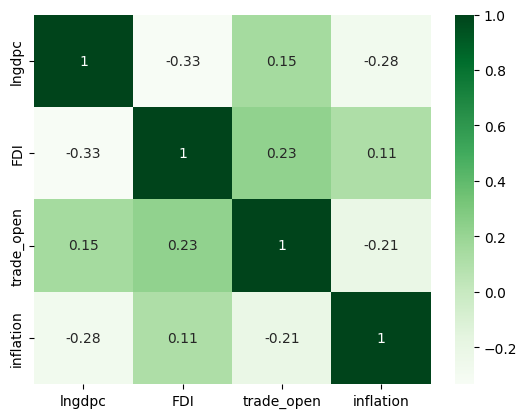

In [9]:
import seaborn as sb
import matplotlib.pyplot as plt

dataplot = sb.heatmap(rho, cmap="Greens", annot=True)

plt.savefig(MODULE_OUTPUT_DIR / "heatmap.png", bbox_inches="tight")

# Q4: How to perform a simple OLS (ordinary least squares) regression?
https://www.statology.org/ols-regression-python/

In [10]:
%pip install -q statsmodels

Note: you may need to restart the kernel to use updated packages.


## 4.2 How to export regression results with a significant asterisk.

In [11]:
%pip install -q openpyxl

Note: you may need to restart the kernel to use updated packages.


In [12]:
import statsmodels.api as sm
from statsmodels.iolib.summary2 import summary_col

# Define the dependent variable.
y = df_reg[["lngdpc"]]

# Define the independent variables.
X1 = df_reg[["FDI"]]
X2 = df_reg[["FDI", "trade_open"]]
X3 = df_reg[["FDI", "trade_open", "inflation"]]

# Add constant terms.
X1 = sm.add_constant(X1)
X2 = sm.add_constant(X2)
X3 = sm.add_constant(X3)

# Fit the OLS models.
model1 = sm.OLS(y, X1).fit()
model2 = sm.OLS(y, X2).fit()
model3 = sm.OLS(y, X3).fit()

# Create a summary table with significance stars.
reg = summary_col(
    [model1, model2, model3],
    stars=True,
    model_names=["Model 1", "Model 2", "Model 3"],
    float_format="%0.2f",
    info_dict={"N": lambda result: result.nobs},
)

reg_df = reg.tables[0].reset_index(drop=False)

# Export the summary table as an Excel file.
reg_df.to_excel(MODULE_OUTPUT_DIR / "regression_results.xlsx", index=False)

reg_df



,index,Model 1,Model 2,Model 3
0,const,9.86***,9.22***,9.49***
1,,(0.11),(0.22),(0.23)
2,FDI,-0.10***,-0.11***,-0.10***
3,,(0.02),(0.02),(0.02)
4,trade_open,,0.01***,0.01***
5,,,(0.00),(0.00)
6,inflation,,,-0.03***
7,,,,(0.01)
8,R-squared,0.11,0.16,0.20
9,R-squared Adj.,0.11,0.15,0.19
